# RFM Segmentation & Retention Strategy
## Part 2 — D2C Customer Churn Intelligence

**Objective:** Build RFM-based customer segments and recommend targeted retention actions before any ML model is deployed.

---

## 0. Setup & Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

# Output folders
os.makedirs('charts', exist_ok=True)
# os.makedirs creates the charts/ folder if it doesn't exist
# exist_ok=True means no error if folder already exists

print('Setup complete.')

Setup complete.


---
## 1. Data Loading

In [26]:
DATA_DIR = 'data/'
# DATA_DIR stores the path to our data folder
# We add it as a prefix to every filename so we don't repeat 'data/' each time

orders       = pd.read_csv(DATA_DIR + 'orders.csv')
customers    = pd.read_csv(DATA_DIR + 'customers.csv')
churn_labels = pd.read_csv(DATA_DIR + 'churn_labels.csv')
support      = pd.read_csv(DATA_DIR + 'support_tickets.csv')
events       = pd.read_csv(DATA_DIR + 'web_events_snapshot.csv')
campaigns    = pd.read_csv(DATA_DIR + 'intervention_history.csv')
rfm_snapshot = pd.read_csv(DATA_DIR + 'rfm_modeling_snapshot.csv')
# rfm_snapshot is the pre-built feature table from the data package
# It already has RFM features calculated — we use this as our base

# Filter orders to pre-snapshot only — same leakage rule as Part 1
# Orders after 2025-09-30 are post-snapshot and must NOT be used as features
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders_pre = orders[orders['order_date'] <= '2025-09-30']

print('=== Dataset Shapes ===')
print(f'rfm_snapshot  : {rfm_snapshot.shape}')  # Our main table
print(f'orders_pre    : {orders_pre.shape}')     # Pre-snapshot orders only
print(f'customers     : {customers.shape}')
print(f'support       : {support.shape}')
print(f'events        : {events.shape}')
print(f'campaigns     : {campaigns.shape}')
print(f'churn_labels  : {churn_labels.shape}')

print('\nrfm_snapshot columns:')
print(rfm_snapshot.columns.tolist())

=== Dataset Shapes ===
rfm_snapshot  : (2400, 29)
orders_pre    : (8137, 10)
customers     : (2400, 9)
support       : (1921, 8)
events        : (2400, 10)
campaigns     : (2400, 5)
churn_labels  : (2400, 4)

rfm_snapshot columns:
['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']


---
## 2. RFM Feature Building

RFM stands for:
- **Recency** — How recently did the customer purchase? (lower = better)
- **Frequency** — How often do they purchase? (higher = better)
- **Monetary** — How much do they spend? (higher = better)

We use the pre-built `rfm_snapshot` table which already has these computed.

In [27]:
# Use rfm_snapshot as our base — it already has RFM features
# recency_days    = days since last purchase (lower = more recent = better)
# frequency_180d  = number of orders in last 180 days (higher = better)
# monetary_180d   = total spend in last 180 days (higher = better)

rfm = rfm_snapshot[[
    'customer_id',
    'recency_days',        # RFM: Recency
    'frequency_180d',      # RFM: Frequency
    'monetary_180d',       # RFM: Monetary
    'return_rate_180d',    # Non-RFM signal 1: Return behaviour
    'avg_discount_pct_180d', # Non-RFM signal 2: Discount sensitivity
    'ticket_count_90d',    # Non-RFM signal 3: Support complaints
    'negative_ticket_rate_90d', # Non-RFM signal 4: Negativity of complaints
    'sessions_30d',        # Non-RFM signal 5: App engagement
    'last_visit_days_ago', # Non-RFM signal 6: Days since last app visit
    'campaign_clicks_30d', # Non-RFM signal 7: Campaign engagement
    'category_diversity_180d', # Non-RFM signal 8: Product diversity
]].copy()
# .copy() creates an independent copy so changes don't affect original

# Merge churn labels so we can verify segments against actual churn
rfm = rfm.merge(
    churn_labels[['customer_id', 'churn_next_60d']],
    on='customer_id', how='left'
)

print(f'RFM table shape: {rfm.shape}')
print(f'\nMissing values:')
print(rfm.isnull().sum())
display(rfm.head())

RFM table shape: (2400, 13)

Missing values:
customer_id                 0
recency_days                0
frequency_180d              0
monetary_180d               0
return_rate_180d            0
avg_discount_pct_180d       0
ticket_count_90d            0
negative_ticket_rate_90d    0
sessions_30d                0
last_visit_days_ago         0
campaign_clicks_30d         0
category_diversity_180d     0
churn_next_60d              0
dtype: int64


,customer_id,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,ticket_count_90d,negative_ticket_rate_90d,sessions_30d,last_visit_days_ago,campaign_clicks_30d,category_diversity_180d,churn_next_60d
0,CUST00001,107,1,362.73,0.00,0.23,0,0.00,1,20,0,1,1
1,CUST00002,40,1,581.00,0.00,0.23,1,0.00,8,0,0,1,0
2,CUST00003,171,1,649.98,0.00,0.47,0,0.00,1,26,0,1,1
3,CUST00004,131,1,1604.04,0.00,0.16,0,0.00,1,14,0,1,1
4,CUST00005,38,3,1781.90,0.00,0.48,0,0.00,18,9,1,2,0


---
## 3. RFM Scoring

We assign scores 1-5 to each RFM dimension using quintiles (equal-sized buckets).
- **R score**: 5 = most recent, 1 = least recent (inverted because lower recency_days = better)
- **F score**: 5 = most frequent, 1 = least frequent
- **M score**: 5 = highest spender, 1 = lowest spender

In [28]:
# Helper function to handle duplicate values in qcut
# duplicates='drop' sometimes still fails when there are too many ties
# So we use rank-based approach instead for problematic columns

def rfm_score(series, reverse=False):
    """
    Scores a series into 1-5 using percentile ranks.
    reverse=True means lower value = higher score (used for Recency)
    reverse=False means higher value = higher score (used for F and M)
    """
    # pct=True gives percentile rank between 0 and 1
    ranked = series.rank(pct=True)
    if reverse:
        ranked = 1 - ranked  # flip so lower values get higher scores
    # Cut into 5 equal bins based on rank
    score = pd.cut(ranked, bins=5, labels=[1,2,3,4,5]).astype(int)
    return score

# Apply scoring
# Recency: reverse=True because LOWER days = MORE recent = BETTER
rfm['R'] = rfm_score(rfm['recency_days'], reverse=True)

# Frequency: reverse=False because HIGHER orders = BETTER
rfm['F'] = rfm_score(rfm['frequency_180d'], reverse=False)

# Monetary: reverse=False because HIGHER spend = BETTER
rfm['M'] = rfm_score(rfm['monetary_180d'], reverse=False)

# Total RFM score (range 3-15)
rfm['RFM_score'] = rfm['R'] + rfm['F'] + rfm['M']

# RFM segment string e.g. '555' = champion
rfm['RFM_segment'] = (rfm['R'].astype(str) + 
                       rfm['F'].astype(str) + 
                       rfm['M'].astype(str))

print('RFM Score Distribution:')
print(rfm['RFM_score'].describe())
print('\nR Score distribution:')
print(rfm['R'].value_counts().sort_index())
print('\nF Score distribution:')
print(rfm['F'].value_counts().sort_index())
print('\nM Score distribution:')
print(rfm['M'].value_counts().sort_index())

RFM Score Distribution:
count   2400.00
mean       8.80
std        3.55
min        3.00
25%        6.00
50%        9.00
75%       12.00
max       15.00
Name: RFM_score, dtype: float64

R Score distribution:
R
1    480
2    471
3    480
4    469
5    500
Name: count, dtype: int64

F Score distribution:
F
1     302
2    1075
4     579
5     444
Name: count, dtype: int64

M Score distribution:
M
1    601
2    449
3    450
4    450
5    450
Name: count, dtype: int64


### Note on F Score Distribution
The missing score 3 in Frequency reflects a real data pattern — 
most customers cluster at 1-2 orders (low frequency) or 4-5 orders 
(loyal buyers), with few in between. This bimodal distribution is 
a business insight in itself — customers are either casual or committed, 
with little middle ground.

---
## 4. Customer Segmentation

We assign business-meaningful segment labels based on RFM scores and non-RFM signals.
We create 6 segments:
1. **Champions** — Best customers: high R, F, M
2. **Loyal Customers** — Frequent buyers but not top spenders
3. **At-Risk Customers** — Were good customers but haven't bought recently
4. **Discount-Sensitive** — Buy mainly when discounts are high
5. **Dormant Customers** — Low recency, low frequency, low monetary
6. **High-Value but Unhappy** — High spend but high support complaints

In [29]:
def assign_segment(row):
    """
    Assigns a business segment to each customer based on their RFM scores
    and non-RFM signals.
    
    Rules are evaluated in order — first match wins.
    """
    r = row['R']  # Recency score 1-5
    f = row['F']  # Frequency score 1-5
    m = row['M']  # Monetary score 1-5
    score = row['RFM_score']  # Total RFM score 3-15
    discount = row['avg_discount_pct_180d']  # Discount usage
    tickets = row['ticket_count_90d']  # Support tickets
    neg_rate = row['negative_ticket_rate_90d']  # Negative ticket rate

    # High-Value but Unhappy: high spend but many negative complaints
    # These need immediate attention before they churn
    if m >= 3 and tickets >= 2 and neg_rate >= 0.3:
        return 'High-Value but Unhappy'

    # Champions: recent, frequent, high spenders
    elif r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    # Loyal Customers: frequent buyers, decent recency
    elif f >= 3 and r >= 3:
        return 'Loyal Customers'

    # At-Risk: used to buy often (high F, high M) but recency has dropped
    elif r <= 2 and f >= 3:
        return 'At-Risk Customers'

    # Discount-Sensitive: only buy when discount is high
    elif discount >= 0.3:
        return 'Discount-Sensitive'

    # Dormant: low across all dimensions — hardest to win back
    else:
        return 'Dormant Customers'

# Apply the function to every row in rfm table
# axis=1 means apply row by row (not column by column)
rfm['segment'] = rfm.apply(assign_segment, axis=1)

print('Segment Distribution:')
seg_counts = rfm['segment'].value_counts()
display(seg_counts.to_frame('count').assign(
    percentage=lambda x: (x['count']/len(rfm)*100).round(1)
))

Segment Distribution:


,count,percentage
segment,,
Dormant Customers,875,36.50
Discount-Sensitive,502,20.90
Champions,388,16.20
Loyal Customers,374,15.60
At-Risk Customers,223,9.30
High-Value but Unhappy,38,1.60


---
## 5. Segment Analysis & Charts

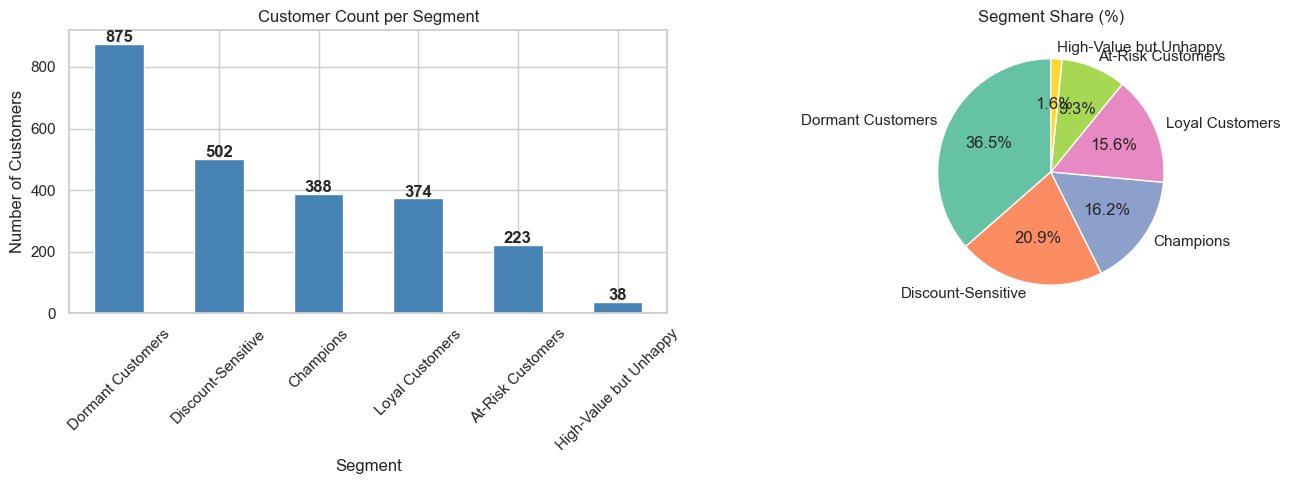

In [30]:
# ── Chart 1: Segment Size Distribution ──
# Shows how many customers fall in each segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Customer Count per Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(seg_counts.values, labels=seg_counts.index,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Segment Share (%)')

plt.tight_layout()
plt.savefig('charts/chart1_segment_distribution.png', dpi=150)
plt.show()

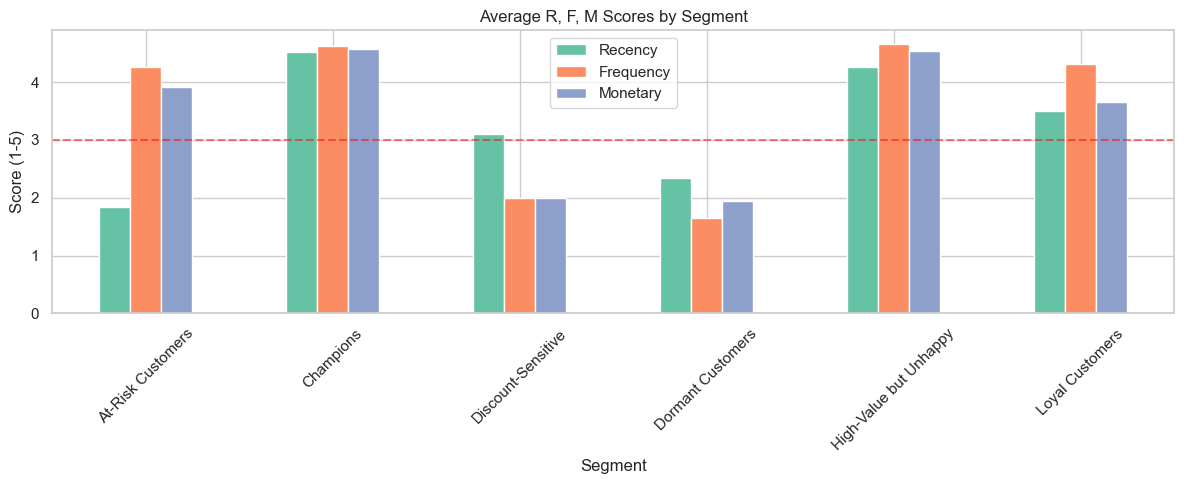

,R,F,M,RFM_score
segment,,,,
At-Risk Customers,1.84,4.26,3.92,10.03
Champions,4.52,4.63,4.58,13.72
Discount-Sensitive,3.10,2.00,2.00,7.11
Dormant Customers,2.34,1.65,1.94,5.93
High-Value but Unhappy,4.26,4.66,4.53,13.45
Loyal Customers,3.50,4.32,3.66,11.48


In [31]:
# ── Chart 2: RFM scores by segment ──
# Shows avg R, F, M score per segment — confirms our segmentation logic is correct
seg_rfm = rfm.groupby('segment')[['R','F','M','RFM_score']].mean().round(2)

fig, ax = plt.subplots(figsize=(12, 5))
seg_rfm[['R','F','M']].plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Average R, F, M Scores by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Score (1-5)')
ax.tick_params(axis='x', rotation=45)
ax.legend(['Recency', 'Frequency', 'Monetary'])
ax.axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Midpoint')

plt.tight_layout()
plt.savefig('charts/chart2_rfm_scores_by_segment.png', dpi=150)
plt.show()
display(seg_rfm)

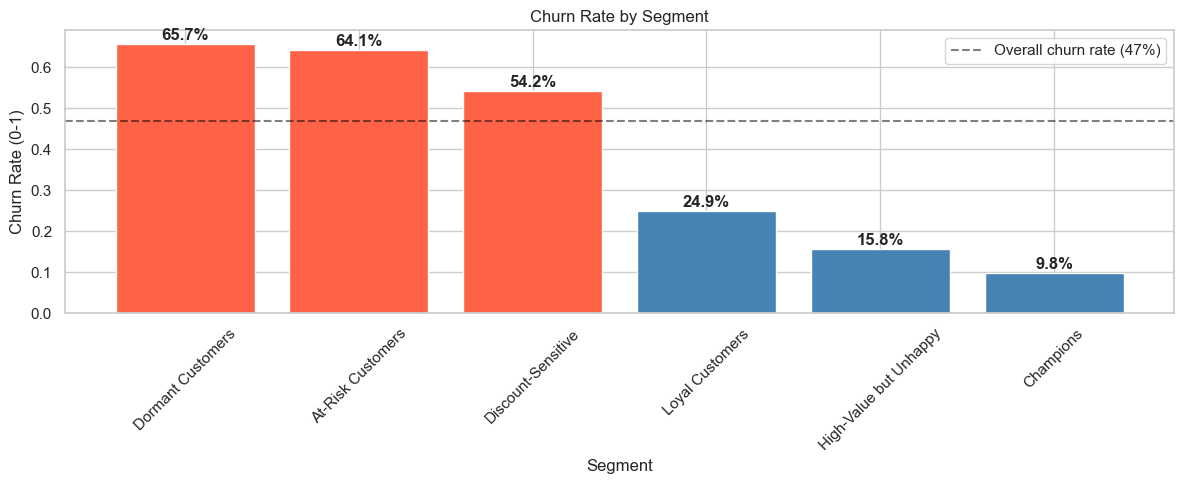

,churn_rate,total,churned
segment,,,
Dormant Customers,0.66,875,575
At-Risk Customers,0.64,223,143
Discount-Sensitive,0.54,502,272
Loyal Customers,0.25,374,93
High-Value but Unhappy,0.16,38,6
Champions,0.10,388,38


In [32]:
# ── Chart 3: Churn rate by segment ──
# Most important chart — shows which segments are most at risk
churn_by_seg = rfm.groupby('segment')['churn_next_60d'].agg(
    churn_rate='mean',
    total='count',
    churned='sum'
).round(3).sort_values('churn_rate', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(churn_by_seg.index, churn_by_seg['churn_rate'],
              color=['tomato' if x > 0.5 else 'steelblue'
                     for x in churn_by_seg['churn_rate']])
ax.set_title('Churn Rate by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Churn Rate (0-1)')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=0.47, color='black', linestyle='--', alpha=0.5, label='Overall churn rate (47%)')
ax.legend()
for i, (idx, row) in enumerate(churn_by_seg.iterrows()):
    ax.text(i, row['churn_rate'] + 0.01, f"{row['churn_rate']*100:.1f}%",
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart3_churn_rate_by_segment.png', dpi=150)
plt.show()
display(churn_by_seg)

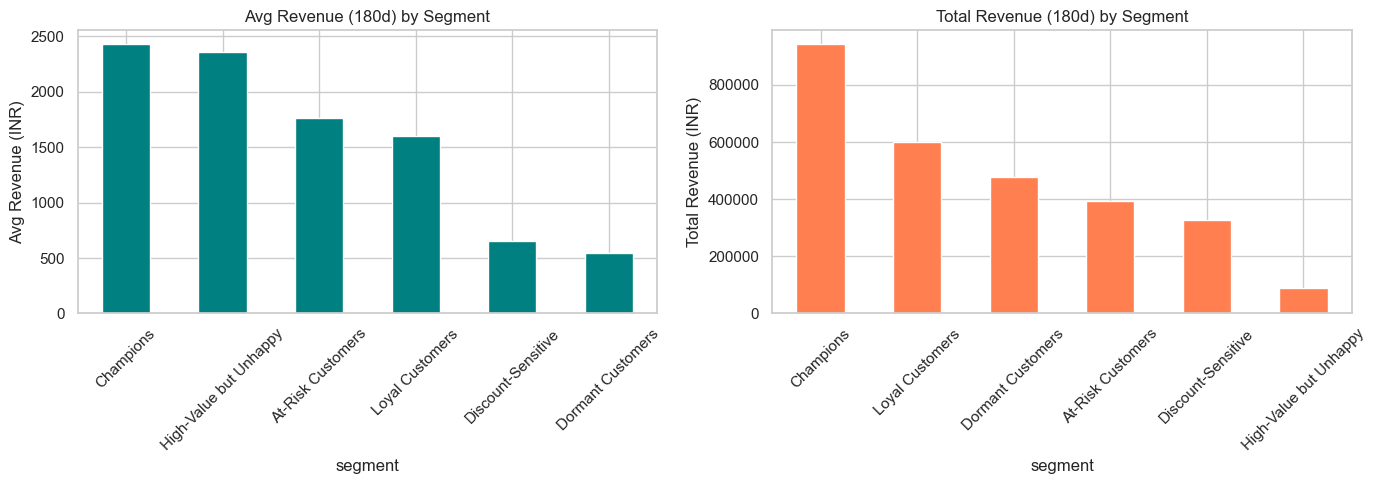

In [33]:
# ── Chart 4: Revenue by segment ──
# Shows monetary value of each segment — helps prioritize retention budget
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rev_by_seg = rfm.groupby('segment')['monetary_180d'].mean().sort_values(ascending=False)
rev_by_seg.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Avg Revenue (180d) by Segment')
axes[0].set_ylabel('Avg Revenue (INR)')
axes[0].tick_params(axis='x', rotation=45)

# Total revenue per segment
total_rev = rfm.groupby('segment')['monetary_180d'].sum().sort_values(ascending=False)
total_rev.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Total Revenue (180d) by Segment')
axes[1].set_ylabel('Total Revenue (INR)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('charts/chart4_revenue_by_segment.png', dpi=150)
plt.show()

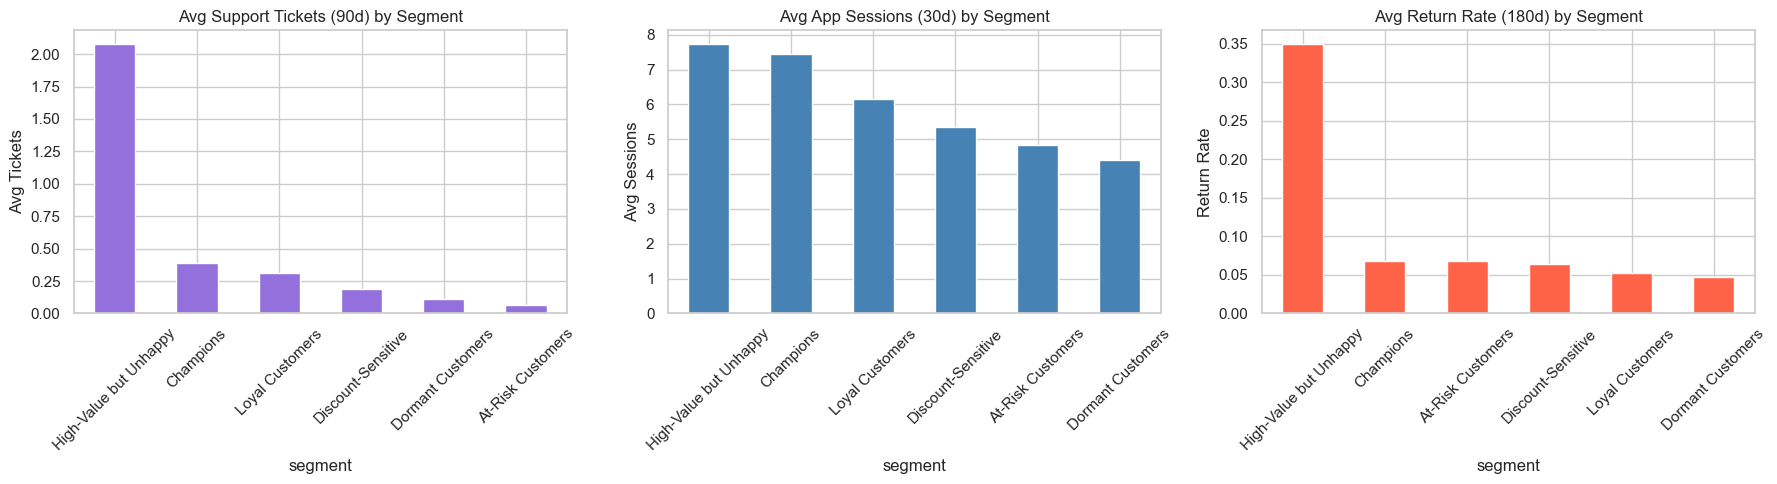

In [34]:
# ── Chart 5: Non-RFM signals by segment ──
# Shows how support complaints and app engagement vary by segment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Support tickets
support_seg = rfm.groupby('segment')['ticket_count_90d'].mean().sort_values(ascending=False)
support_seg.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Avg Support Tickets (90d) by Segment')
axes[0].set_ylabel('Avg Tickets')
axes[0].tick_params(axis='x', rotation=45)

# App sessions
session_seg = rfm.groupby('segment')['sessions_30d'].mean().sort_values(ascending=False)
session_seg.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Avg App Sessions (30d) by Segment')
axes[1].set_ylabel('Avg Sessions')
axes[1].tick_params(axis='x', rotation=45)

# Return rate
return_seg = rfm.groupby('segment')['return_rate_180d'].mean().sort_values(ascending=False)
return_seg.plot(kind='bar', ax=axes[2], color='tomato', edgecolor='white')
axes[2].set_title('Avg Return Rate (180d) by Segment')
axes[2].set_ylabel('Return Rate')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('charts/chart5_nonrfm_signals_by_segment.png', dpi=150)
plt.show()

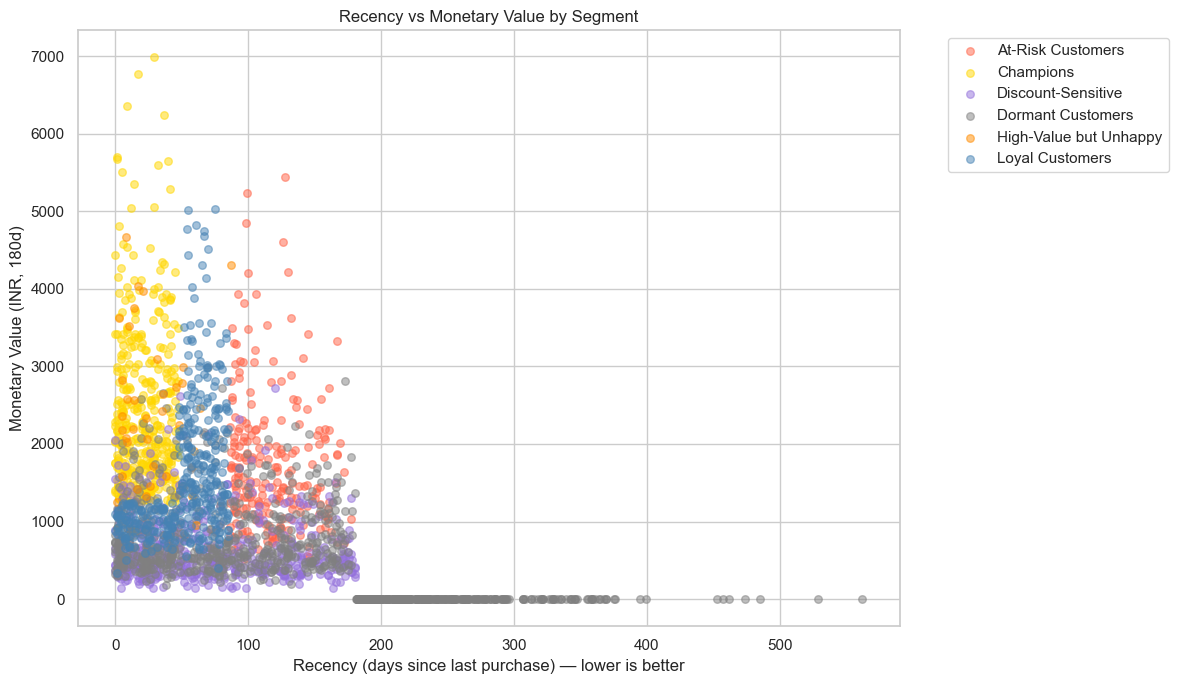

In [35]:
# ── Chart 6: Recency vs Monetary coloured by segment ──
# Scatter plot shows natural clustering of segments
fig, ax = plt.subplots(figsize=(12, 7))

colors = {
    'Champions': 'gold',
    'Loyal Customers': 'steelblue',
    'At-Risk Customers': 'tomato',
    'Discount-Sensitive': 'mediumpurple',
    'Dormant Customers': 'gray',
    'High-Value but Unhappy': 'darkorange'
}

for segment, group in rfm.groupby('segment'):
    ax.scatter(
        group['recency_days'],
        group['monetary_180d'],
        label=segment,
        alpha=0.5,
        color=colors.get(segment, 'black'),
        s=30
    )

ax.set_title('Recency vs Monetary Value by Segment')
ax.set_xlabel('Recency (days since last purchase) — lower is better')
ax.set_ylabel('Monetary Value (INR, 180d)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('charts/chart6_recency_vs_monetary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Full Segment Summary Table

In [36]:
# Full summary of all segments with all key metrics
# This table goes into the retention_strategy.md
segment_summary = rfm.groupby('segment').agg(
    customer_count      = ('customer_id', 'count'),
    churn_rate          = ('churn_next_60d', 'mean'),
    avg_recency_days    = ('recency_days', 'mean'),
    avg_frequency       = ('frequency_180d', 'mean'),
    avg_monetary        = ('monetary_180d', 'mean'),
    avg_return_rate     = ('return_rate_180d', 'mean'),
    avg_discount_pct    = ('avg_discount_pct_180d', 'mean'),
    avg_tickets         = ('ticket_count_90d', 'mean'),
    avg_sessions        = ('sessions_30d', 'mean'),
).round(2)

# Convert churn rate to percentage for readability
segment_summary['churn_rate_%'] = (segment_summary['churn_rate'] * 100).round(1)

print('=== Full Segment Summary ===')
display(segment_summary)

=== Full Segment Summary ===


,customer_count,churn_rate,avg_recency_days,avg_frequency,avg_monetary,avg_return_rate,avg_discount_pct,avg_tickets,avg_sessions,churn_rate_%
segment,,,,,,,,,,
At-Risk Customers,223,0.64,117.86,2.38,1767.04,0.07,0.28,0.06,4.83,64.00
Champions,388,0.10,20.98,3.08,2432.53,0.07,0.27,0.39,7.45,10.00
Discount-Sensitive,502,0.54,72.92,1.00,654.06,0.06,0.39,0.19,5.35,54.00
Dormant Customers,875,0.66,135.63,0.65,544.67,0.05,0.12,0.11,4.40,66.00
High-Value but Unhappy,38,0.16,25.61,3.34,2363.40,0.35,0.28,2.08,7.74,16.00
Loyal Customers,374,0.25,50.87,2.41,1601.13,0.05,0.28,0.31,6.15,25.00


---
## 7. Save segments.csv

Required output: `segments.csv` with customer_id, segment_name, and key features.

In [37]:
# Create segments.csv with required columns
# Must contain: customer_id, segment_name + important features used for segmentation
segments_output = rfm[[
    'customer_id',
    'segment',              # segment_name
    'R', 'F', 'M',         # individual RFM scores
    'RFM_score',            # total RFM score
    'recency_days',         # raw recency
    'frequency_180d',       # raw frequency
    'monetary_180d',        # raw monetary
    'return_rate_180d',     # non-RFM signal 1
    'ticket_count_90d',     # non-RFM signal 2
    'sessions_30d',         # non-RFM signal 3
    'avg_discount_pct_180d', # non-RFM signal 4
    'churn_next_60d',       # actual churn label for reference
]].rename(columns={'segment': 'segment_name'})
# rename() changes column name 'segment' to 'segment_name' as required

# Save to CSV
segments_output.to_csv('segments.csv', index=False)
# index=False means don't write row numbers to the file

print(f'segments.csv saved: {segments_output.shape}')
display(segments_output.head())
print('\nSegment counts:')
print(segments_output['segment_name'].value_counts())

segments.csv saved: (2400, 14)


,customer_id,segment_name,R,F,M,RFM_score,recency_days,frequency_180d,monetary_180d,return_rate_180d,ticket_count_90d,sessions_30d,avg_discount_pct_180d,churn_next_60d
0,CUST00001,Dormant Customers,2,2,1,5,107,1,362.73,0.00,0,1,0.23,1
1,CUST00002,Dormant Customers,4,2,2,8,40,1,581.00,0.00,1,8,0.23,0
2,CUST00003,Discount-Sensitive,1,2,2,5,171,1,649.98,0.00,0,1,0.47,1
3,CUST00004,Dormant Customers,2,2,4,8,131,1,1604.04,0.00,0,1,0.16,1
4,CUST00005,Champions,4,5,4,13,38,3,1781.90,0.00,0,18,0.48,0



Segment counts:
segment_name
Dormant Customers         875
Discount-Sensitive        502
Champions                 388
Loyal Customers           374
At-Risk Customers         223
High-Value but Unhappy     38
Name: count, dtype: int64


---
## 8. Manual Review Cases

Identify 10 customers where the retention decision is NOT straightforward — mixed signals that make segment assignment ambiguous.

In [38]:
# Find customers with CONTRADICTORY signals — these are the hard cases
# Example: High monetary but very low recency (lapsed high-value customer)
# Example: High frequency but very high return rate (buys a lot but returns a lot)
# Example: Low RFM but received campaign and still churned

# Case Type 1: High monetary (M>=4) but low recency (R<=2) — lapsed high value
case1 = rfm[(rfm['M'] >= 4) & (rfm['R'] <= 2)].head(3)

# Case Type 2: High frequency (F>=4) but high return rate (>0.5) — buys but returns
case2 = rfm[(rfm['F'] >= 4) & (rfm['return_rate_180d'] > 0.5)].head(3)

# Case Type 3: Low RFM score but high sessions — browsing but not buying
case3 = rfm[(rfm['RFM_score'] <= 6) & (rfm['sessions_30d'] >= 10)].head(2)

# Case Type 4: High support complaints but still purchasing
case4 = rfm[(rfm['ticket_count_90d'] >= 4) & (rfm['F'] >= 3)].head(2)

# Combine all cases
manual_cases = pd.concat([case1, case2, case3, case4]).drop_duplicates(
    subset='customer_id'
).head(10)

print(f'Manual review cases found: {len(manual_cases)}')
display(manual_cases[[
    'customer_id', 'segment', 'R', 'F', 'M', 'RFM_score',
    'recency_days', 'frequency_180d', 'monetary_180d',
    'return_rate_180d', 'ticket_count_90d', 'sessions_30d',
    'churn_next_60d'
]])

Manual review cases found: 8


,customer_id,segment,R,F,M,RFM_score,recency_days,frequency_180d,monetary_180d,return_rate_180d,ticket_count_90d,sessions_30d,churn_next_60d
3,CUST00004,Dormant Customers,2,2,4,8,131,1,1604.04,0.00,0,1,1
41,CUST00042,High-Value but Unhappy,2,5,5,12,87,5,4306.00,0.00,2,3,0
56,CUST00057,Dormant Customers,2,2,4,8,136,1,1713.34,0.00,0,7,1
177,CUST00178,High-Value but Unhappy,5,4,4,13,5,2,1583.88,1.00,2,10,0
262,CUST00263,Champions,4,5,4,13,25,3,1618.39,0.67,2,15,0
437,CUST00438,High-Value but Unhappy,3,5,5,13,64,3,2466.39,1.00,2,6,1
24,CUST00025,Discount-Sensitive,1,2,2,5,165,1,517.97,0.00,0,11,1
65,CUST00066,Dormant Customers,1,1,1,3,320,0,0.00,0.00,0,11,1
